In [109]:
import torch
from sklearn.datasets import make_circles

In [110]:
n_samples = 1000

X, y = make_circles(n_samples,noise=0.03,random_state=42)   

In [111]:
import pandas as pd

circles  = pd.DataFrame({'X1':X[:,0],'X2':X[:,1],'label':y})
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

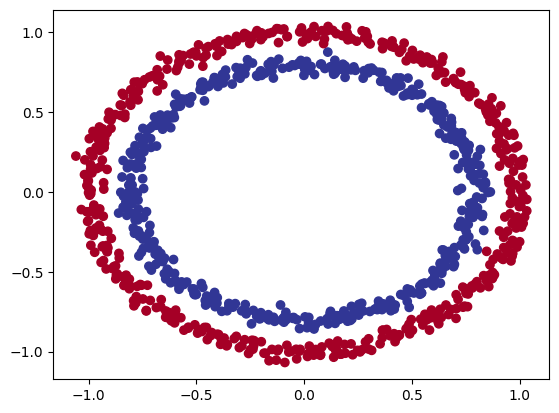

In [112]:
import matplotlib.pyplot as plt

plt.scatter(x=X[:,0],y=X[:,1],c=y,cmap=plt.cm.RdYlBu)

In [113]:
X.shape ,y.shape

((1000, 2), (1000,))

In [114]:
import torch

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [115]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [116]:
from torch import nn

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [117]:
class circleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2,out_features=5)
        self.layer_2 = nn.Linear(in_features=5,out_features=1)

    def forward(self,x):
        return self.layer_2(self.layer_1(x))

model_0 = circleModel().to(device)
model_0


circleModel(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [118]:
untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")


Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[-0.1269],
        [-0.0967],
        [-0.1908],
        [-0.1089],
        [-0.1667],
        [-0.1484],
        [-0.0826],
        [-0.0946],
        [-0.1918],
        [-0.0944]], device='cuda:0', grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [119]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.001)

In [120]:
def accuracy(y_true,y_pred):
    check = torch.eq(y_true,y_pred).sum().item()
    return (check / len(y_pred))*100

In [121]:
torch.manual_seed(42)
ephochs = 100

X_train,y_train = X_train.to(device),y_train.to(device)
X_test,y_test = X_test.to(device),y_test.to(device)

for epoch in range(ephochs):
    model_0.train()

    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits,y_train)
    acc = accuracy(y_true=y_train,y_pred=y_pred)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_0.eval()
    with torch.inference_mode():
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_pred,y_test)
        test_acc = accuracy(y_true=y_test,y_pred=test_pred)
    
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69569, Accuracy: 50.00% | Test loss: 0.69315, Test acc: 50.00%
Epoch: 10 | Loss: 0.69566, Accuracy: 50.00% | Test loss: 0.69315, Test acc: 50.00%
Epoch: 20 | Loss: 0.69563, Accuracy: 50.00% | Test loss: 0.69315, Test acc: 50.00%
Epoch: 30 | Loss: 0.69561, Accuracy: 50.00% | Test loss: 0.69315, Test acc: 50.00%
Epoch: 40 | Loss: 0.69558, Accuracy: 50.00% | Test loss: 0.69315, Test acc: 50.00%
Epoch: 50 | Loss: 0.69556, Accuracy: 50.00% | Test loss: 0.69315, Test acc: 50.00%
Epoch: 60 | Loss: 0.69553, Accuracy: 50.00% | Test loss: 0.69315, Test acc: 50.00%
Epoch: 70 | Loss: 0.69551, Accuracy: 50.00% | Test loss: 0.69315, Test acc: 50.00%
Epoch: 80 | Loss: 0.69549, Accuracy: 50.00% | Test loss: 0.69315, Test acc: 50.00%
Epoch: 90 | Loss: 0.69546, Accuracy: 50.00% | Test loss: 0.69315, Test acc: 50.00%


In [122]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


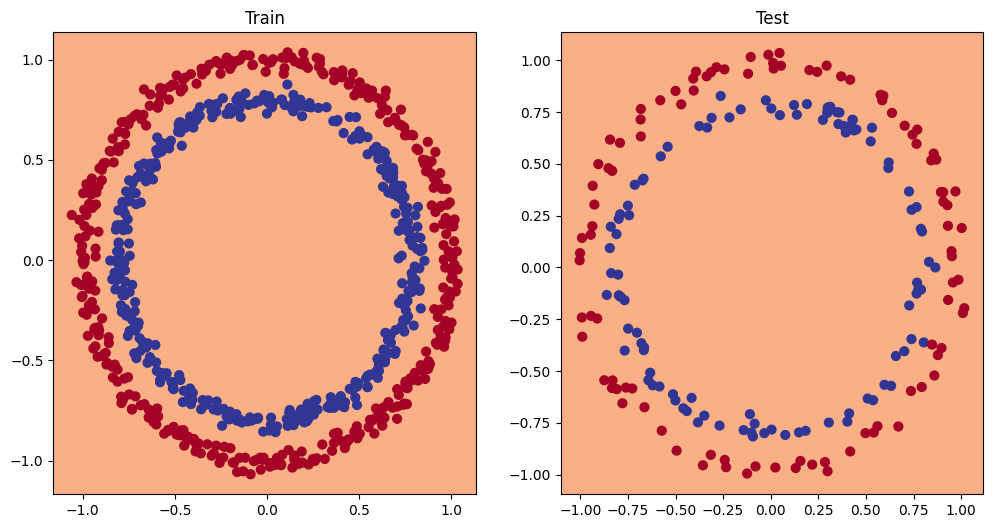

In [123]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

In [124]:
class circleModel_V2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features=2,out_features=10)
        self.layer2 = nn.Linear(in_features=10,out_features=10)
        self.layer3 = nn.Linear(in_features=10,out_features=1)
        self.ReLu = nn.ReLU()

    def forward(self,x):
        return self.layer3(self.ReLu(self.layer2(self.ReLu(self.layer1(x)))))

model_3 = circleModel_V2().to(device)
print(model_3)


circleModel_V2(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
  (ReLu): ReLU()
)


In [125]:
oss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(), lr=0.1)

In [126]:
torch.manual_seed(42)
epochs = 10000

X_train,y_train = X_train.to(device),y_train.to(device)
X_test,y_test = X_test.to(device),y_test.to(device)

for epoch in range(epochs):
    model_3.train()

    y_logits = model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits,y_train)
    acc = accuracy(y_true=y_train,y_pred=y_pred) 

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_3.eval()
    with torch.inference_mode():
        test_logits = model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_pred,y_test)
        test_acc = accuracy(y_true=y_test,y_pred=test_pred)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69295, Accuracy: 50.00% | Test Loss: 0.81326, Test Accuracy: 50.00%
Epoch: 100 | Loss: 0.69115, Accuracy: 52.88% | Test Loss: 0.71248, Test Accuracy: 52.50%
Epoch: 200 | Loss: 0.68977, Accuracy: 53.37% | Test Loss: 0.70418, Test Accuracy: 55.00%
Epoch: 300 | Loss: 0.68795, Accuracy: 53.00% | Test Loss: 0.70279, Test Accuracy: 56.00%
Epoch: 400 | Loss: 0.68517, Accuracy: 52.75% | Test Loss: 0.70089, Test Accuracy: 56.50%
Epoch: 500 | Loss: 0.68102, Accuracy: 52.75% | Test Loss: 0.70089, Test Accuracy: 56.50%
Epoch: 600 | Loss: 0.67515, Accuracy: 54.50% | Test Loss: 0.70278, Test Accuracy: 56.00%
Epoch: 700 | Loss: 0.66659, Accuracy: 58.38% | Test Loss: 0.68899, Test Accuracy: 59.00%
Epoch: 800 | Loss: 0.65160, Accuracy: 64.00% | Test Loss: 0.65189, Test Accuracy: 67.50%
Epoch: 900 | Loss: 0.62362, Accuracy: 74.00% | Test Loss: 0.60460, Test Accuracy: 79.00%
Epoch: 1000 | Loss: 0.56818, Accuracy: 87.75% | Test Loss: 0.56650, Test Accuracy: 86.50%
Epoch: 1100 | Loss: 0.

In [127]:
model_3.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()

y_preds[:10], y[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0.]))

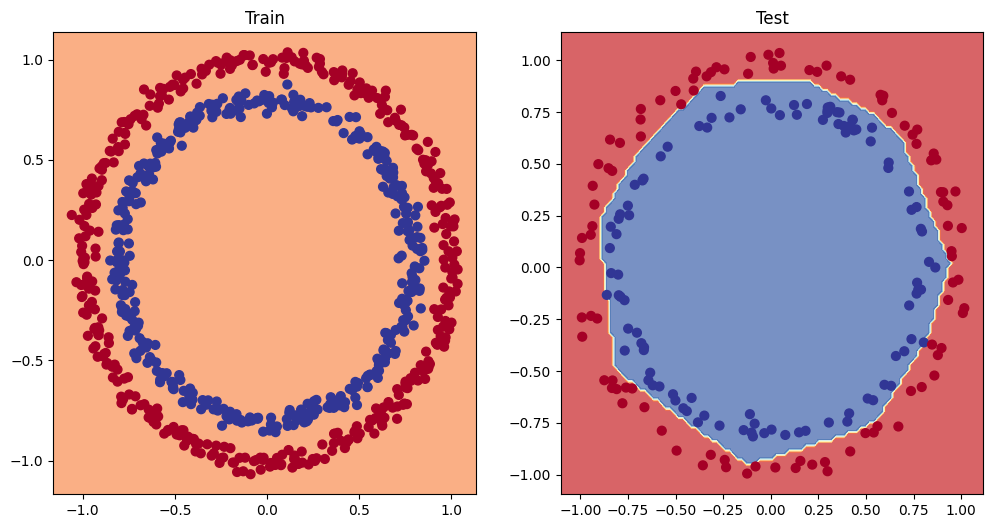

In [129]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train) # model_1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test) # model_3 = has non-linearity

Creating Multi-Class classification data

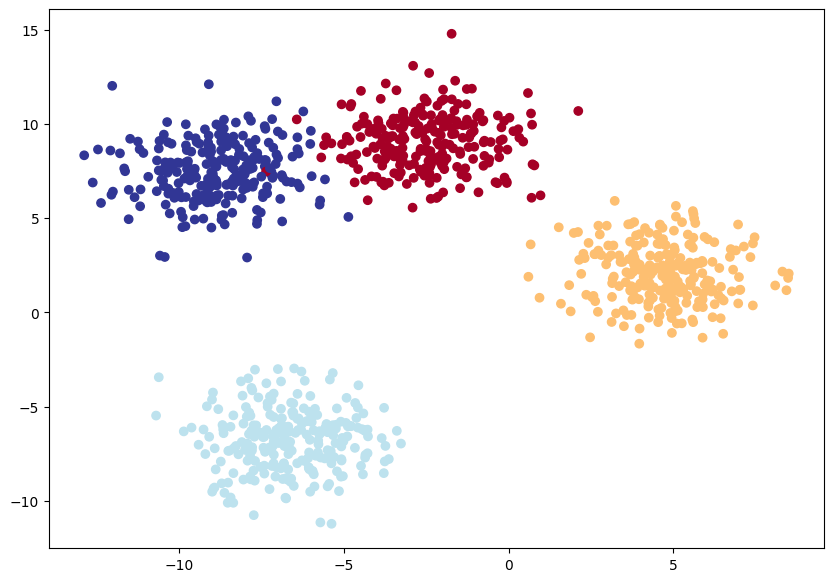

In [132]:
from sklearn.datasets import make_blobs

no_classes = 4
no_features = 2
random_seed = 42

X_blob , y_blob = make_blobs(n_samples=1000, centers=no_classes,n_features=no_features,random_state=random_seed,cluster_std=1.5)

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

X_blob_train,X_blob_test,y_blob_train,y_blob_test = train_test_split(X_blob,y_blob,test_size=0.2,random_state=random_seed)

plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu);


In [136]:

class MultiClassModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=no_features,out_features=hidden_units),
            nn.Linear(in_features=hidden_units,out_features=hidden_units),
            nn.Linear(in_features=hidden_units,out_features=output_features)
        )

    def forward(self,x):
        return self.linear_layer_stack(x)
    
model_4 = MultiClassModel(input_features=no_features,output_features=no_classes).to(device)
model_4

MultiClassModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [137]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_4.parameters(),lr=0.001)


In [138]:
model_4(X_blob_train.to(device))[:5]

tensor([[ 0.8696, -0.7083, -0.3200,  0.5513],
        [-0.1989, -2.0320,  0.4267, -1.2864],
        [-0.9819, -0.0741,  1.0288, -1.7247],
        [-0.6449, -0.4877,  0.7777, -1.4029],
        [-0.2937, -1.7872,  0.4998, -1.3371]], device='cuda:0',
       grad_fn=<SliceBackward0>)

In [139]:
model_4(X_blob_train.to(device))[0].shape, no_classes

(torch.Size([4]), 4)

In [140]:
# Make prediction logits with model
y_logits = model_4(X_blob_test.to(device))

# Perform softmax calculation on logits across dimension 1 to get prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1) 
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[ 0.8161, -0.8846, -0.2847,  0.4252],
        [-0.9359, -2.0669,  0.9583, -2.2816],
        [-0.6742, -0.0694,  0.8067, -1.3123],
        [ 0.6858, -0.5307, -0.1840,  0.3610],
        [ 0.1430, -1.9414,  0.1816, -0.8017]], device='cuda:0',
       grad_fn=<SliceBackward0>)
tensor([[0.4563, 0.0833, 0.1518, 0.3087],
        [0.1215, 0.0392, 0.8077, 0.0316],
        [0.1289, 0.2361, 0.5669, 0.0681],
        [0.4102, 0.1215, 0.1719, 0.2964],
        [0.3918, 0.0487, 0.4072, 0.1523]], device='cuda:0',
       grad_fn=<SliceBackward0>)


In [141]:
torch.sum(y_pred_probs[0])

tensor(1., device='cuda:0', grad_fn=<SumBackward0>)

In [146]:
torch.manual_seed(42)
epochs = 10000 

X_blob_train,y_blob_train = X_blob_train.to(device),y_blob_train.to(device)
X_blob_test,y_blob_test = X_blob_test.to(device),y_blob_test.to(device)

for epoch in range(epochs):
    model_4.train()

    y_logits = model_4(X_blob_train)
    y_pred = torch.softmax(y_logits,dim=1).argmax(dim=1)

    loss = loss_fn(y_logits,y_blob_train)
    acc = accuracy(y_true=y_blob_train,y_pred=y_pred)

    optimizer.zero_grad()
    loss.backward() 
    optimizer.step()

    model_4.eval()
    with torch.inference_mode():
        test_logits = model_4(X_blob_test)
        test_pred = torch.softmax(test_logits,dim=1).argmax(dim=1)

        test_loss = loss_fn(test_logits,y_blob_test)
        test_acc  = accuracy(y_true=y_blob_test,y_pred=test_pred)
    
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%") 

Epoch: 0 | Loss: 0.03526, Acc: 99.00% | Test Loss: 0.02690, Test Acc: 99.50%
Epoch: 10 | Loss: 0.03525, Acc: 99.00% | Test Loss: 0.02689, Test Acc: 99.50%
Epoch: 20 | Loss: 0.03524, Acc: 99.00% | Test Loss: 0.02688, Test Acc: 99.50%
Epoch: 30 | Loss: 0.03523, Acc: 99.00% | Test Loss: 0.02687, Test Acc: 99.50%
Epoch: 40 | Loss: 0.03522, Acc: 99.00% | Test Loss: 0.02686, Test Acc: 99.50%
Epoch: 50 | Loss: 0.03521, Acc: 99.00% | Test Loss: 0.02684, Test Acc: 99.50%
Epoch: 60 | Loss: 0.03520, Acc: 99.00% | Test Loss: 0.02683, Test Acc: 99.50%
Epoch: 70 | Loss: 0.03519, Acc: 99.00% | Test Loss: 0.02682, Test Acc: 99.50%
Epoch: 80 | Loss: 0.03518, Acc: 99.00% | Test Loss: 0.02681, Test Acc: 99.50%
Epoch: 90 | Loss: 0.03518, Acc: 99.00% | Test Loss: 0.02680, Test Acc: 99.50%
Epoch: 100 | Loss: 0.03517, Acc: 99.00% | Test Loss: 0.02679, Test Acc: 99.50%
Epoch: 110 | Loss: 0.03516, Acc: 99.00% | Test Loss: 0.02678, Test Acc: 99.50%
Epoch: 120 | Loss: 0.03515, Acc: 99.00% | Test Loss: 0.02676, T

In [147]:
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test)

# View the first 10 predictions
y_logits[:10]

tensor([[ 11.1075,  18.9419, -11.0772,  -5.1746],
        [ -0.7520, -23.3968,  -2.2876,   6.2696],
        [-16.9515, -29.6957,  17.2994,   7.3480],
        [  5.8652,  12.7306,  -5.3526,  -3.6471],
        [ 12.4977,   6.8522, -14.6160,  -1.7002],
        [ -1.5934, -28.7354,  -2.0074,   7.7408],
        [-15.7039, -23.8370,  16.5814,   5.7474],
        [  8.7209,  -1.2098, -11.0194,   0.4133],
        [-19.9706, -39.6891,  19.6524,  10.0397],
        [  9.9177,   1.6903, -12.1084,  -0.3540]], device='cuda:0')

In [148]:
# Turn predicted logits in prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)

# Turn prediction probabilities into prediction labels
y_preds = y_pred_probs.argmax(dim=1)

# Compare first 10 model preds and test labels
print(f"Predictions: {y_preds[:10]}\nLabels: {y_blob_test[:10]}")
print(f"Test accuracy: {accuracy(y_true=y_blob_test, y_pred=y_preds)}%")

Predictions: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')
Labels: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')
Test accuracy: 99.5%


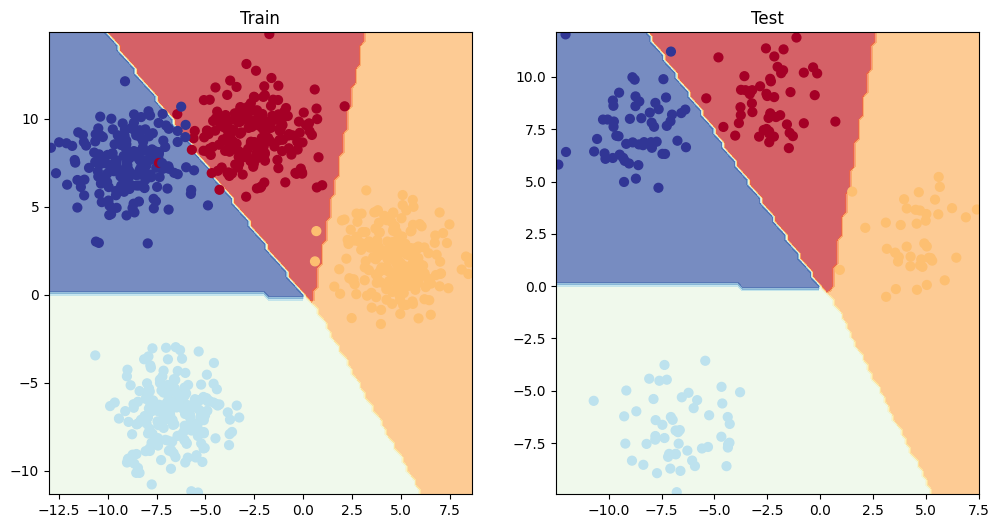

In [149]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)